# 01 · Calidad de Datos y Análisis Exploratorio (EDA)
### ShopSmart Recommender — Sistema de recomendación de moda en Amazon

**Objetivo de este notebook**

1. Evaluar y tratar la **calidad de los datos**: valores faltantes,
   duplicados, tipos de dato inconsistentes, outliers y desbalance de
   clases.
2. Realizar un **EDA completo** con visualizaciones clave que permitan
   entender la distribución de productos, precios, categorías, ratings y
   reseñas, sentando las bases para el diseño del sistema de
   recomendación.
3. Dejar **datasets limpios y documentados** en `data/processed/`, listos
   para ser consumidos por Power BI y por el próximo notebook de
   ingeniería de características.

**Dataset:** [Amazon E-commerce Product and Review Dataset](https://www.kaggle.com/datasets/lazylad99/amazon-e-commerce-product-and-review-dataset)
— 728 productos y 6.327 reseñas de ropa y accesorios.

**Metodología:** en cada sección se documenta el hallazgo, la decisión
tomada y su justificación, siguiendo un enfoque reproducible y orientado
a un caso de uso real de un sistema de recomendación híbrido.

## 0. Configuración del entorno

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import missingno as msno
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from wordcloud import STOPWORDS, WordCloud

# Permite importar los módulos reutilizables de src/ sin instalar el paquete
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.data.cleaning import (  # noqa: E402
    extract_main_category,
    fix_encoding,
    normalize_availability,
    parse_price,
    parse_rating_count,
    parse_rating_stars,
    parse_recent_purchases,
    parse_review_metadata,
)
from src.data.load_data import load_products, load_reviews  # noqa: E402

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name: str) -> None:
    """Guarda una figura en `reports/figures/` en formato PNG de alta calidad."""
    fig.savefig(FIGURES_DIR / f"{name}.png", bbox_inches="tight", dpi=150)

## 1. Carga de datos

In [2]:
df_products_raw = load_products()
df_reviews_raw = load_reviews()

print(f"products.csv -> {df_products_raw.shape[0]:,} filas x {df_products_raw.shape[1]} columnas")
print(f"reviews.csv  -> {df_reviews_raw.shape[0]:,} filas x {df_reviews_raw.shape[1]} columnas")

products.csv -> 728 filas x 34 columnas
reviews.csv  -> 6,327 filas x 23 columnas


In [3]:
df_products_raw.head(3)

,s.no,about_item,asin,availability,best_sellers_rank,brand_name,brand_page_url,breadcrumbs,customer_review_summary,default_variant/0,...,rating_distribution/4star,rating_distribution/5star,rating_stars,recent_purchases,scrape_time,seller_name,seller_page_url,title,all_images,rank_1
0,0,Premium Comfort: Crafted from a high-quality c...,B0B59BJG6Y,In Stock,"#56,836 in Clothing, Shoes & Jewelry (See Top ...",MLYENX Store,https://www.amazon.com/stores/MLYENX/page/1FCD...,"Clothing, Shoes & Jewelry › Men › Clothing › A...",Customers find the shirts comfortable and well...,size:Large,...,15%,75%,4.6 out of 5 stars,50+ bought,03-10-2025 21:42,Greenfive,https://www.amazon.com/gp/help/seller/at-a-gla...,4/5 Pack Mens Polo Shirts Short Sleeve Quick D...,['https://m.media-amazon.com/images/I/41yUF65P...,85.0
1,1,Material: Men's polo shirt is made of soft pol...,B0DLGB4RYH,In Stock,"#50,261 in Clothing, Shoes & Jewelry (See Top ...",COOFANDY Store,https://www.amazon.com/stores/COOFANDY/page/23...,"Clothing, Shoes & Jewelry › Men › Clothing › S...",NaN,size:X-Large,...,17%,66%,4.4 out of 5 stars,NaN,03-10-2025 21:42,COOFANDY,https://www.amazon.com/gp/help/seller/at-a-gla...,COOFANDY Men's Polo Shirts Short Sleeve Moistu...,['https://m.media-amazon.com/images/I/31a3mSs3...,199.0
2,2,"PERFORMANCE:These men polo shirts are soft,lig...",B0DRXF62JH,In Stock,"#69,641 in Clothing, Shoes & Jewelry (See Top ...",ZITY Store,https://www.amazon.com/stores/ZITY/page/F582B6...,"Clothing, Shoes & Jewelry › Men › Clothing › A...",NaN,size:X-Large,...,37%,63%,4.6 out of 5 stars,NaN,03-10-2025 21:42,ZITY®,https://www.amazon.com/gp/help/seller/at-a-gla...,ZITY 3 Pack Men Polo Shirts Short Sleeve with ...,['https://m.media-amazon.com/images/I/41J5q-Ua...,111.0


In [4]:
df_reviews_raw.head(3)

,s.no,helpfulVoteCount,images/0,images/1,images/2,images/3,images/4,images/5,images/6,images/7,...,reviewID,reviewMetadata,reviewPosition,reviewText,reviewTitle,reviewURL,verifiedPurchase,videos/0,cleaned_review_text,sentiment_score
0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,R2AUQFPJY5ERCZ,"Reviewed in the United States on March 6, 2025",1,‚úçÔ∏è The COOFANDY Men's Polo Shirt is a fant...,Stylish and Lightweight COOFANDY Polo Shirt,https://www.amazon.com/review/R2AUQFPJY5ERCZ,False,NaN,coofandy men polo shirt fantastic blend style ...,0.292024
1,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,R1YNLJ0QFLB1VT,"Reviewed in the United States on March 7, 2025",1,I love these. They look good. They fit well. T...,New favorite shirts,https://www.amazon.com/review/R1YNLJ0QFLB1VT,False,NaN,love look good fit well comfortable breathable...,0.560000
2,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,R11LIYW9RMDK9R,"Reviewed in the United States on February 27, ...",2,My expectations were low -- how good could shi...,Incredibly Good Deal,https://www.amazon.com/review/R11LIYW9RMDK9R,False,NaN,expectation low good could shirt sell one mist...,0.192321


### 1.1 Diccionario de datos

El detalle de cada columna está documentado en `doc/diccionario.txt`. En
resumen:

- **`products.csv`**: metadatos de producto (marca, precio, categoría,
  ranking, rating agregado, disponibilidad, imágenes, etc.).
- **`reviews.csv`**: reseñas de clientes (texto, rating individual,
  sentimiento, votos útiles, país/fecha, si la compra fue verificada).

Ambas tablas se relacionan mediante `products.asin` <-> `reviews.productASIN`.

## 2. Panorama general y tipos de dato

In [5]:
df_products_raw.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 728 entries, 0 to 727
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   s.no                       728 non-null    int64  
 1   about_item                 728 non-null    str    
 2   asin                       728 non-null    str    
 3   availability               715 non-null    str    
 4   best_sellers_rank          558 non-null    str    
 5   brand_name                 728 non-null    str    
 6   brand_page_url             649 non-null    str    
 7   breadcrumbs                715 non-null    str    
 8   customer_review_summary    634 non-null    str    
 9   default_variant/0          696 non-null    str    
 10  default_variant/1          658 non-null    str    
 11  default_variant/2          1 non-null      str    
 12  delivery_date              702 non-null    str    
 13  fastest_delivery_date      667 non-null    str    
 14  list_

In [6]:
df_reviews_raw.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 6327 entries, 0 to 6326
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   s.no                 6327 non-null   int64  
 1   helpfulVoteCount     6327 non-null   int64  
 2   images/0             516 non-null    str    
 3   images/1             212 non-null    str    
 4   images/2             98 non-null     str    
 5   images/3             49 non-null     str    
 6   images/4             26 non-null     str    
 7   images/5             14 non-null     str    
 8   images/6             7 non-null      str    
 9   images/7             5 non-null      str    
 10  productASIN          6327 non-null   str    
 11  productVariant       5836 non-null   str    
 12  rating               6320 non-null   float64
 13  reviewID             6327 non-null   str    
 14  reviewMetadata       6296 non-null   str    
 15  reviewPosition       6327 non-null   int64  
 16 

**Hallazgo:** varias columnas que deberían ser numéricas llegan como texto
libre producto del scraping (por ejemplo `rating_stars`,
`rating_count`, `list_price`, `recent_purchases` en `products`, y
`reviewMetadata` en `reviews`, que mezcla país y fecha en un solo string).
Esto se corrige en la sección 4 (Estandarización de tipos).

## 3. Integridad referencial y duplicados

In [7]:
n_dup_asin = df_products_raw["asin"].duplicated().sum()
n_dup_review_id = df_reviews_raw["reviewID"].duplicated().sum()
n_dup_rows_products = df_products_raw.duplicated().sum()
n_dup_rows_reviews = df_reviews_raw.duplicated().sum()
orphan_reviews = (~df_reviews_raw["productASIN"].isin(df_products_raw["asin"])).sum()

integrity_summary = pd.DataFrame(
    {
        "chequeo": [
            "ASIN duplicado en products",
            "reviewID duplicado en reviews",
            "Filas 100% duplicadas en products",
            "Filas 100% duplicadas en reviews",
            "Reseñas huérfanas (ASIN sin producto asociado)",
        ],
        "resultado": [
            n_dup_asin,
            n_dup_review_id,
            n_dup_rows_products,
            n_dup_rows_reviews,
            orphan_reviews,
        ],
    }
)
integrity_summary

,chequeo,resultado
0,ASIN duplicado en products,0
1,reviewID duplicado en reviews,0
2,Filas 100% duplicadas en products,0
3,Filas 100% duplicadas en reviews,0
4,Reseñas huérfanas (ASIN sin producto asociado),0


**Hallazgo:** no se detectan ASIN ni `reviewID` duplicados, no hay filas
completamente duplicadas y el 100% de las reseñas están asociadas a un
producto existente. **La integridad referencial del dataset es sólida**,
por lo que no se requiere eliminar registros por este motivo.

## 4. Valores faltantes

### 4.1 Diagnóstico — `products.csv`

In [8]:
missing_products = (
    df_products_raw.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("pct_faltante")
    .to_frame()
)
missing_products = missing_products[missing_products["pct_faltante"] > 0]
missing_products

,pct_faltante
default_variant/2,99.862637
model_number,72.664835
manufacturer,63.461538
product_description,62.774725
list_price,44.917582
seller_page_url,41.483516
rank_1,25.824176
best_sellers_rank,23.351648
recent_purchases,21.840659
customer_review_summary,12.912088


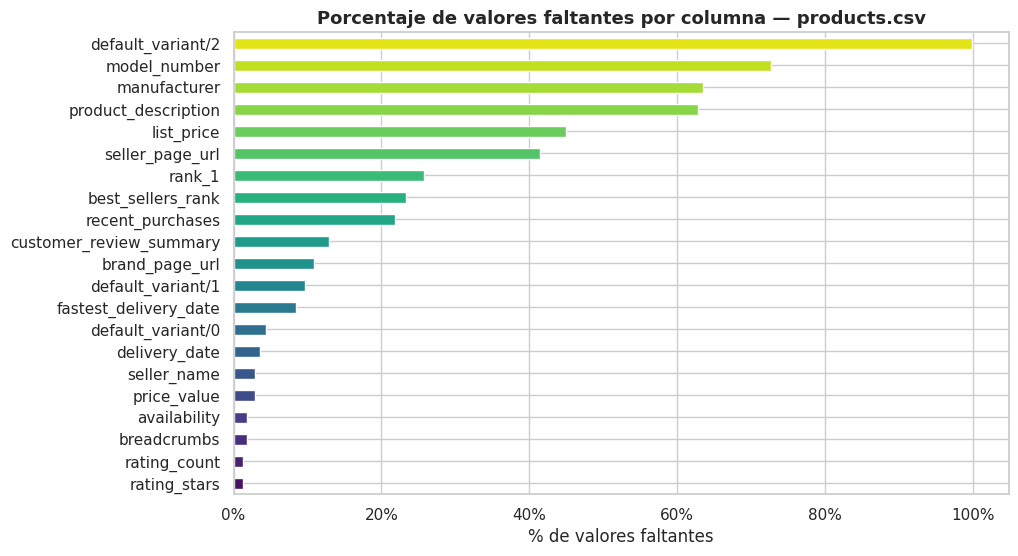

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
missing_products["pct_faltante"].sort_values().plot(
    kind="barh", ax=ax, color=sns.color_palette("viridis", len(missing_products))
)
ax.set_title("Porcentaje de valores faltantes por columna — products.csv")
ax.set_xlabel("% de valores faltantes")
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
save_fig(fig, "01_missing_products")
plt.show()

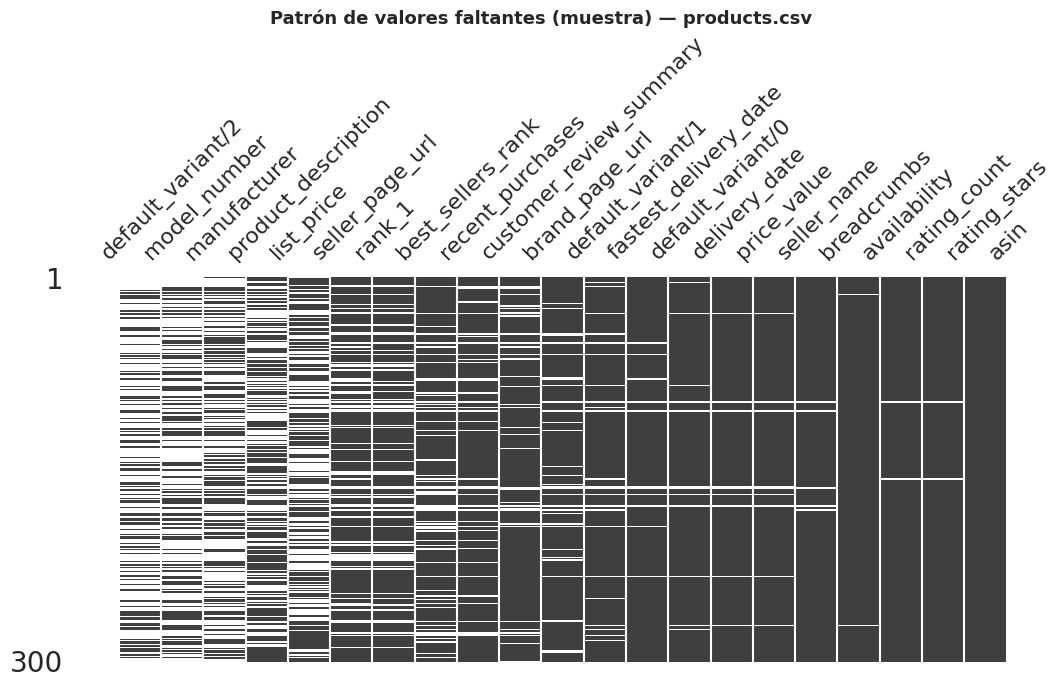

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))
msno.matrix(
    df_products_raw[missing_products.index.tolist() + ["asin"]].sample(
        min(300, len(df_products_raw)), random_state=RANDOM_SEED
    ),
    ax=ax,
    sparkline=False,
)
ax.set_title("Patrón de valores faltantes (muestra) — products.csv")
save_fig(fig, "02_missing_pattern_products")
plt.show()

### 4.2 Diagnóstico — `reviews.csv`

In [11]:
missing_reviews = (
    df_reviews_raw.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("pct_faltante")
    .to_frame()
)
missing_reviews = missing_reviews[missing_reviews["pct_faltante"] > 0]
missing_reviews

,pct_faltante
images/7,99.920974
images/6,99.889363
images/5,99.778726
images/4,99.589063
videos/0,99.462621
images/3,99.225541
images/2,98.451083
images/1,96.649281
images/0,91.844476
productVariant,7.760392


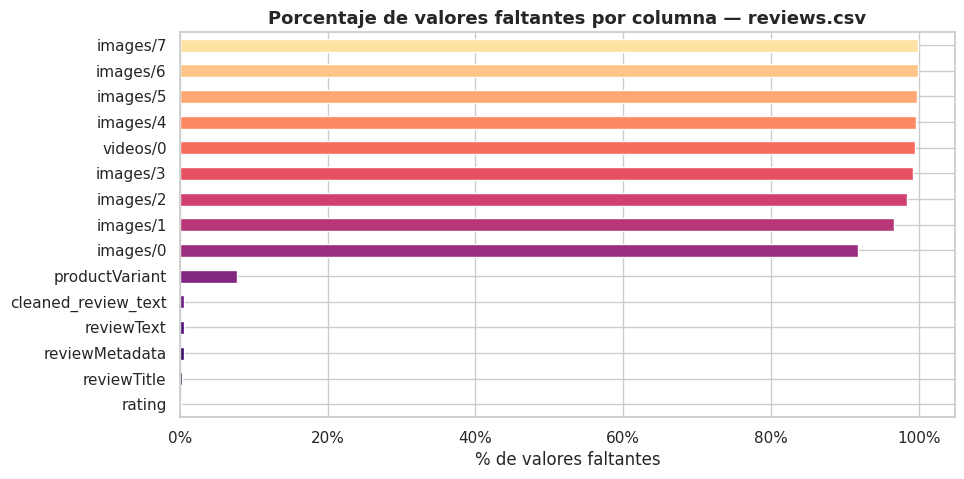

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
missing_reviews["pct_faltante"].sort_values().plot(
    kind="barh", ax=ax, color=sns.color_palette("magma", len(missing_reviews))
)
ax.set_title("Porcentaje de valores faltantes por columna — reviews.csv")
ax.set_xlabel("% de valores faltantes")
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
save_fig(fig, "03_missing_reviews")
plt.show()

### 4.3 Interpretación y estrategia de tratamiento

| Columna | % faltante | Mecanismo probable | Decisión |
|---|---|---|---|
| `default_variant/2` | ~99.9% | MNAR: solo aplica a productos con 3 atributos de variante (ej. talla+color+ajuste) | Se descarta la columna: no aporta señal generalizable |
| `model_number`, `manufacturer` | ~63–73% | MCAR: campo opcional no siempre completado por el vendedor | Se conserva; se imputa como `"No especificado"` (categoría explícita) |
| `product_description` | ~63% | MCAR: Amazon no siempre muestra descripción extendida | Se conserva como texto; ausencia se trata como `""` (no se usa en modelos de similitud si está vacía) |
| `list_price` | ~45% | MAR: solo existe cuando el producto tiene descuento activo | Se imputa con `price_value` (precio actual) cuando falta -> asumimos "sin descuento" |
| `seller_page_url`, `brand_page_url` | 10–41% | MCAR: metadatos de navegación, sin relevancia analítica | Se descartan para el modelado (se mantienen en crudo por trazabilidad) |
| `rank_1`, `best_sellers_rank` | 24–26% | MAR: solo productos con ventas suficientes tienen ranking | Se imputa con un valor centinela alto (peor rank) + flag booleano `has_rank` |
| `recent_purchases` | ~22% | MAR: Amazon oculta esta métrica en productos de bajo volumen | Se imputa como 0 + flag booleano `has_recent_purchases` |
| `customer_review_summary` | ~13% | MAR: requiere un mínimo de reseñas generadas por IA de Amazon | Se imputa como `""` (ausencia de resumen es información válida: pocas reseñas) |
| `price_value`, `rating_count`, `rating_stars` | 1–3% | MCAR | Se imputan con la mediana (numéricas robustas a outliers) |
| `reviewText`, `cleaned_review_text`, `reviewTitle` (reviews) | 0.2–0.6% | MCAR | Se eliminan esas filas: sin texto no hay reseña utilizable para NLP/sentimiento |
| `rating` (reviews) | 0.1% | MCAR | Se eliminan esas filas: variable objetivo del filtrado colaborativo |
| `productVariant` | ~7.8% | MAR: no todos los productos tienen variantes | Se imputa como `"Estándar"` |
| `images/*`, `videos/0` (reviews) | 92–100% | MNAR: la mayoría de los clientes no adjunta fotos/videos | Se descartan; se reemplazan por un flag `has_media` |

La regla general aplicada es: **nunca imputar ciegamente con la media/moda
sin antes entender si la ausencia del dato es en sí misma informativa**
(por ejemplo, no tener `recent_purchases` visible en Amazon típicamente
indica bajo volumen de ventas, no un error de captura).

## 5. Estandarización de tipos de dato

Antes de imputar valores faltantes, se deben parsear los campos de texto
libre a tipos numéricos/fecha reales; de lo contrario cualquier imputación
o detección de outliers sería inválida.

In [13]:
df_products = df_products_raw.copy()

# Campos numéricos ocultos en texto libre
df_products["price_value"] = df_products["price_value"].astype(float)
df_products["list_price_value"] = df_products["list_price"].apply(parse_price)
df_products["rating_stars_num"] = df_products["rating_stars"].apply(parse_rating_stars)
df_products["rating_count_num"] = df_products["rating_count"].apply(parse_rating_count)
df_products["recent_purchases_num"] = df_products["recent_purchases"].apply(
    parse_recent_purchases
)

# Categóricos normalizados
df_products["availability_clean"] = df_products["availability"].apply(
    normalize_availability
)
df_products["main_category"] = df_products["breadcrumbs"].apply(extract_main_category)

# Fechas
df_products["scrape_time"] = pd.to_datetime(
    df_products["scrape_time"], format="%m-%d-%Y %H:%M", errors="coerce"
)

# Corrección de encoding (mojibake) en campos de texto libre
for col in ["about_item", "product_description", "customer_review_summary", "title"]:
    df_products[col] = df_products[col].apply(fix_encoding)

print("Nuevas columnas numéricas/fecha parseadas correctamente:")
df_products[
    [
        "price_value",
        "list_price_value",
        "rating_stars_num",
        "rating_count_num",
        "recent_purchases_num",
        "availability_clean",
        "main_category",
    ]
].head()

Nuevas columnas numéricas/fecha parseadas correctamente:


,price_value,list_price_value,rating_stars_num,rating_count_num,recent_purchases_num,availability_clean,main_category
0,39.9926,53.99,4.6,1654.0,50.0,In Stock,Men
1,19.9920,24.99,4.4,20.0,NaN,In Stock,Men
2,29.9950,59.99,4.6,5.0,NaN,In Stock,Men
3,32.9500,NaN,4.8,22.0,NaN,In Stock,Men
4,26.9931,38.99,4.4,2175.0,NaN,In Stock,Men


In [14]:
df_reviews = df_reviews_raw.copy()

review_meta = df_reviews["reviewMetadata"].apply(parse_review_metadata)
df_reviews = pd.concat([df_reviews, review_meta], axis=1)

for col in ["reviewText", "reviewTitle", "cleaned_review_text"]:
    df_reviews[col] = df_reviews[col].apply(fix_encoding)

df_reviews["review_length_words"] = df_reviews["reviewText"].fillna("").apply(
    lambda t: len(str(t).split())
)

df_reviews[["review_country", "review_date", "review_length_words"]].head()

,review_country,review_date,review_length_words
0,United States,2025-03-06,222
1,United States,2025-03-07,51
2,United States,2025-02-27,162
3,United States,2025-02-26,82
4,United States,2025-02-20,48


## 6. Tratamiento de valores faltantes

Aplicamos la estrategia justificada en la sección 4.3.

In [15]:
# --- products.csv ---------------------------------------------------------
df_products = df_products.drop(
    columns=[
        "default_variant/2",
        "seller_page_url",
        "brand_page_url",
        "default_variant/0",
        "default_variant/1",
        "list_price",
        "rating_stars",
        "rating_count",
        "recent_purchases",
        "availability",
        "breadcrumbs",
    ]
)

df_products["model_number"] = df_products["model_number"].fillna("No especificado")
df_products["manufacturer"] = df_products["manufacturer"].fillna("No especificado")
df_products["product_description"] = df_products["product_description"].fillna("")
df_products["customer_review_summary"] = df_products["customer_review_summary"].fillna("")

df_products["has_rank"] = df_products["rank_1"].notna()
df_products["rank_1"] = df_products["rank_1"].fillna(df_products["rank_1"].max() + 1)

df_products["has_recent_purchases"] = df_products["recent_purchases_num"].notna()
df_products["recent_purchases_num"] = df_products["recent_purchases_num"].fillna(0)

# `price_value` se imputa primero con la mediana, para poder usarlo a su vez
# como respaldo de `list_price_value` (precio "sin descuento" cuando no
# existe un list_price explícito).
for col in ["price_value", "rating_count_num", "rating_stars_num"]:
    df_products[col] = df_products[col].fillna(df_products[col].median())

df_products["list_price_value"] = df_products["list_price_value"].fillna(
    df_products["price_value"]
)

df_products["main_category"] = df_products["main_category"].fillna("Sin categoría")
df_products["availability_clean"] = df_products["availability_clean"].fillna("Other")

# --- reviews.csv ------------------------------------------------------------
media_cols = [c for c in df_reviews.columns if c.startswith(("images/", "videos/"))]
df_reviews["has_media"] = df_reviews[media_cols].notna().any(axis=1)
df_reviews = df_reviews.drop(columns=media_cols + ["reviewMetadata"])

df_reviews["productVariant"] = df_reviews["productVariant"].fillna("Estándar")

rows_before = len(df_reviews)
df_reviews = df_reviews.dropna(subset=["reviewText", "rating", "cleaned_review_text"])
rows_after = len(df_reviews)

# reviewMetadata no siempre pudo parsearse (formato con fecha en negrilla,
# distinto del regex esperado); no se descartan estas reseñas (el texto y el
# rating siguen siendo válidos), solo se marca el país como "Desconocido".
df_reviews["review_country"] = df_reviews["review_country"].fillna("Desconocido")
df_reviews["reviewTitle"] = df_reviews["reviewTitle"].fillna("Sin título")

print(f"products.csv -> {df_products.isna().sum().sum()} valores nulos restantes")
print(f"reviews.csv  -> {df_reviews.isna().sum().sum()} valores nulos restantes")
print(
    f"reviews.csv  -> se eliminaron {rows_before - rows_after} filas "
    f"({(rows_before - rows_after) / rows_before:.2%}) sin texto/rating utilizable"
)

products.csv -> 278 valores nulos restantes
reviews.csv  -> 0 valores nulos restantes
reviews.csv  -> se eliminaron 39 filas (0.62%) sin texto/rating utilizable


In [16]:
remaining_missing = pd.concat(
    [
        df_products.isna().mean().mul(100).rename("products (%)"),
        df_reviews.isna().mean().mul(100).rename("reviews (%)"),
    ],
    axis=1,
)
remaining_missing[(remaining_missing > 0).any(axis=1)].fillna("-")

,products (%),reviews (%)
best_sellers_rank,23.351648,-
delivery_date,3.571429,-
fastest_delivery_date,8.379121,-
seller_name,2.884615,-


**Hallazgo:** tras el tratamiento, ambos datasets quedan prácticamente sin
valores nulos. Las excepciones remanentes (`review_date`) corresponden a
los pocos casos (~0.5%) en los que `reviewMetadata` no siguió el formato
esperado; se conservan como `NaT` porque el texto y el rating de esas
reseñas siguen siendo válidos y útiles para el modelado.

## 7. Detección y tratamiento de outliers

Se aplica el **método del rango intercuartílico (IQR)**, robusto frente a
distribuciones asimétricas como las de precios y conteos de reseñas,
típicas en e-commerce.

In [17]:
def iqr_outlier_bounds(series: pd.Series, k: float = 1.5) -> tuple[float, float]:
    """Calcula los límites inferior/superior de outliers según el método IQR."""
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr


numeric_cols_products = {
    "price_value": "Precio actual (USD)",
    "rating_count_num": "Cantidad de ratings",
    "recent_purchases_num": "Compras recientes",
}

outlier_report = []
for col, label in numeric_cols_products.items():
    lower, upper = iqr_outlier_bounds(df_products[col])
    n_out = ((df_products[col] < lower) | (df_products[col] > upper)).sum()
    outlier_report.append(
        {
            "columna": label,
            "límite_inferior": round(lower, 2),
            "límite_superior": round(upper, 2),
            "n_outliers": n_out,
            "% outliers": round(100 * n_out / len(df_products), 2),
        }
    )

pd.DataFrame(outlier_report)

,columna,límite_inferior,límite_superior,n_outliers,% outliers
0,Precio actual (USD),-10.04,70.03,35,4.81
1,Cantidad de ratings,-19941.75,35266.25,88,12.09
2,Compras recientes,-775.00,1425.00,54,7.42


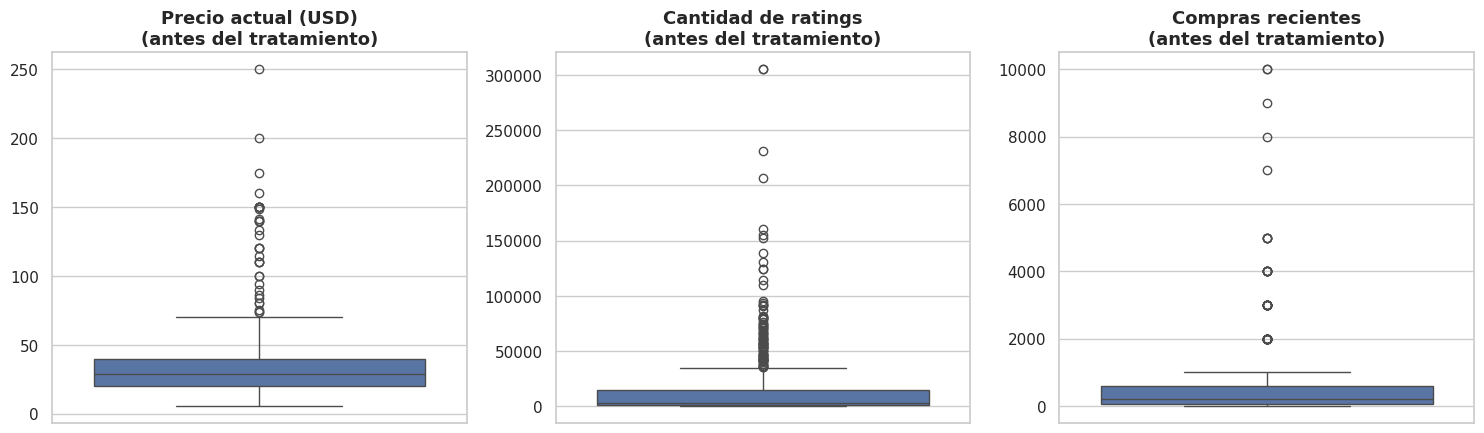

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (col, label) in zip(axes, numeric_cols_products.items()):
    sns.boxplot(y=df_products[col], ax=ax, color="#4C72B0")
    ax.set_title(f"{label}\n(antes del tratamiento)")
    ax.set_ylabel("")
fig.tight_layout()
save_fig(fig, "04_boxplots_outliers_before")
plt.show()

**Hallazgo:** `price_value`, `rating_count_num` y `recent_purchases_num`
presentan outliers superiores esperables en un catálogo real de
e-commerce (algunos productos "best seller" con miles de reseñas y
compras, y algunas prendas premium de alto precio). **No se trata de
errores de captura**: son productos legítimos con comportamiento
extremo pero informativo para el recomendador (justamente los productos
más populares son señal fuerte de calidad/demanda).

**Decisión:** en lugar de eliminarlos (perderíamos productos relevantes),
se aplica **winsorización** (recorte al percentil 99) solo sobre
`price_value`, ya que es la variable que más distorsiona modelos basados
en distancia (ej. similitud de contenido). Para `rating_count_num` y
`recent_purchases_num` se conserva el valor original y se crean
variables log-transformadas, más apropiadas para variables de conteo con
cola larga.

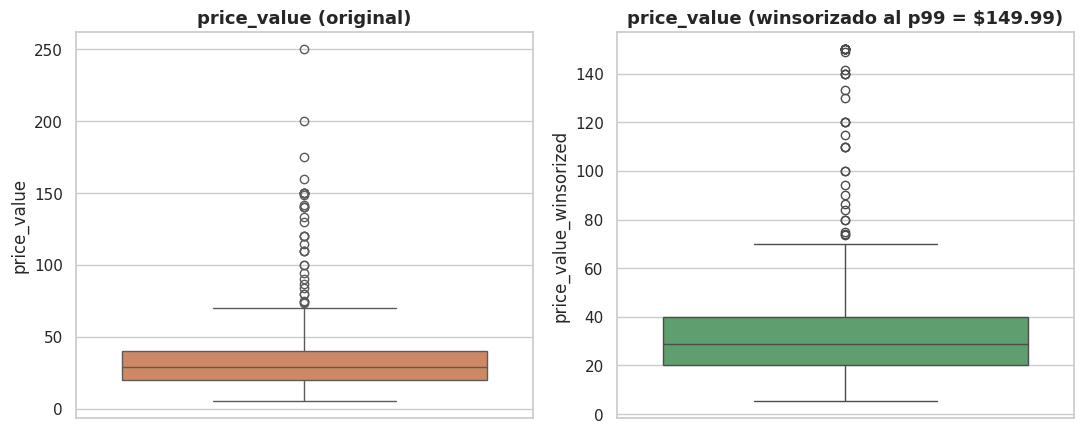

In [19]:
p99_price = df_products["price_value"].quantile(0.99)
df_products["price_value_winsorized"] = df_products["price_value"].clip(upper=p99_price)

df_products["rating_count_log"] = np.log1p(df_products["rating_count_num"])
df_products["recent_purchases_log"] = np.log1p(df_products["recent_purchases_num"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.boxplot(y=df_products["price_value"], ax=axes[0], color="#DD8452")
axes[0].set_title("price_value (original)")
sns.boxplot(y=df_products["price_value_winsorized"], ax=axes[1], color="#55A868")
axes[1].set_title(f"price_value (winsorizado al p99 = ${p99_price:.2f})")
fig.tight_layout()
save_fig(fig, "05_boxplot_price_winsorized")
plt.show()

### 7.1 Outliers en reseñas: `helpfulVoteCount` y longitud de reseña

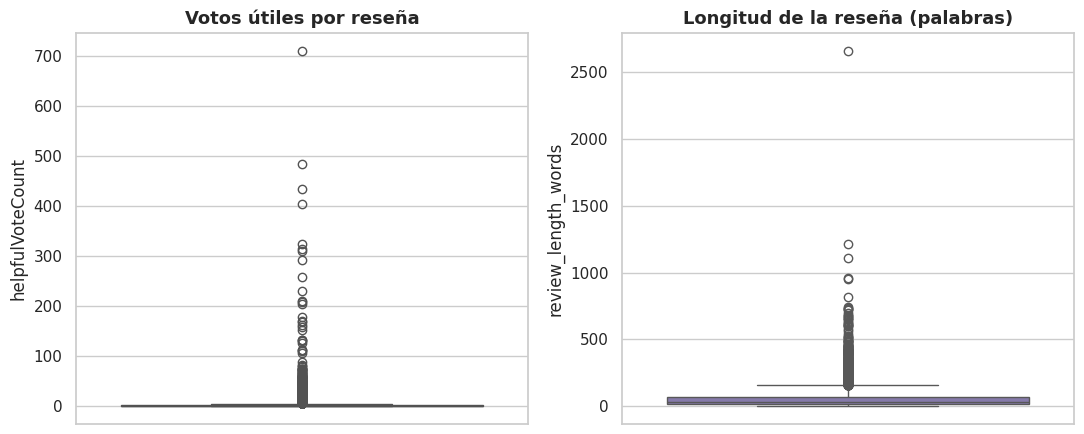

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.boxplot(y=df_reviews["helpfulVoteCount"], ax=axes[0], color="#C44E52")
axes[0].set_title("Votos útiles por reseña")
sns.boxplot(y=df_reviews["review_length_words"], ax=axes[1], color="#8172B2")
axes[1].set_title("Longitud de la reseña (palabras)")
fig.tight_layout()
save_fig(fig, "06_boxplots_reviews_outliers")
plt.show()

**Hallazgo:** `helpfulVoteCount` tiene una distribución extremadamente
sesgada (mediana 0, máximo 710): la mayoría de las reseñas no reciben
votos, y unas pocas se vuelven muy populares. Esto es un patrón esperado
en plataformas de reseñas (ley de potencias), no un error.

**Decisión:** se crea `helpful_vote_log` (log1p) para su uso en modelos,
y se conserva la columna original para reporting descriptivo. No se
eliminan filas.

In [21]:
df_reviews["helpful_vote_log"] = np.log1p(df_reviews["helpfulVoteCount"])

## 8. Desbalance de clases

Relevante tanto para el análisis de sentimiento (rating como proxy de
sentimiento) como para cualquier tarea de clasificación posterior
(ej. predecir si una reseña será positiva/negativa).

### 8.1 Distribución de `rating` en reseñas

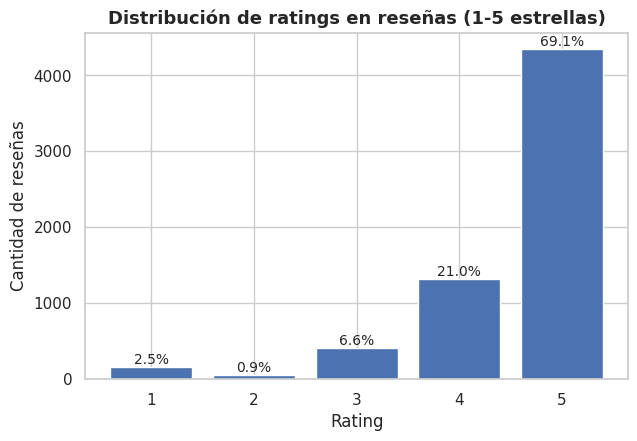

Ratio de desbalance (5★ vs 1★): 27.7x


In [22]:
rating_counts = df_reviews["rating"].value_counts().sort_index()
rating_pct = (rating_counts / rating_counts.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(rating_counts.index.astype(int), rating_counts.values, color="#4C72B0")
for bar, pct in zip(bars, rating_pct):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{pct}%",
        ha="center",
        va="bottom",
        fontsize=10,
    )
ax.set_title("Distribución de ratings en reseñas (1-5 estrellas)")
ax.set_xlabel("Rating")
ax.set_ylabel("Cantidad de reseñas")
save_fig(fig, "07_rating_distribution_reviews")
plt.show()

print(f"Ratio de desbalance (5★ vs 1★): {rating_counts[5] / rating_counts[1]:.1f}x")

**Hallazgo:** el dataset está **fuertemente desbalanceado hacia
reseñas positivas** — cerca del **90% de las reseñas son de 4-5
estrellas**, frente a solo ~3% de 1-2 estrellas. Esto es habitual en
plataformas de e-commerce (sesgo de autoselección: quien compra y no
tiene problemas rara vez deja reseña).

**Implicancia para el sistema de recomendación:**
- Para el **filtrado colaborativo**, este desbalance no es crítico en sí
  mismo (se trabaja con ratings, no con clases), pero sí debe
  considerarse al construir la matriz usuario-producto: la ausencia de
  rating no equivale a rating negativo.
- Si en etapas posteriores se entrena un **clasificador de sentimiento**
  (positivo/negativo) sobre `rating`, será necesario aplicar
  estratificación en el split y/o balanceo de clases (`class_weight`,
  sobremuestreo de la clase minoritaria) para evitar que el modelo
  colapse prediciendo siempre "positivo".

### 8.2 Distribución de `rating_stars` en productos y de la categoría principal

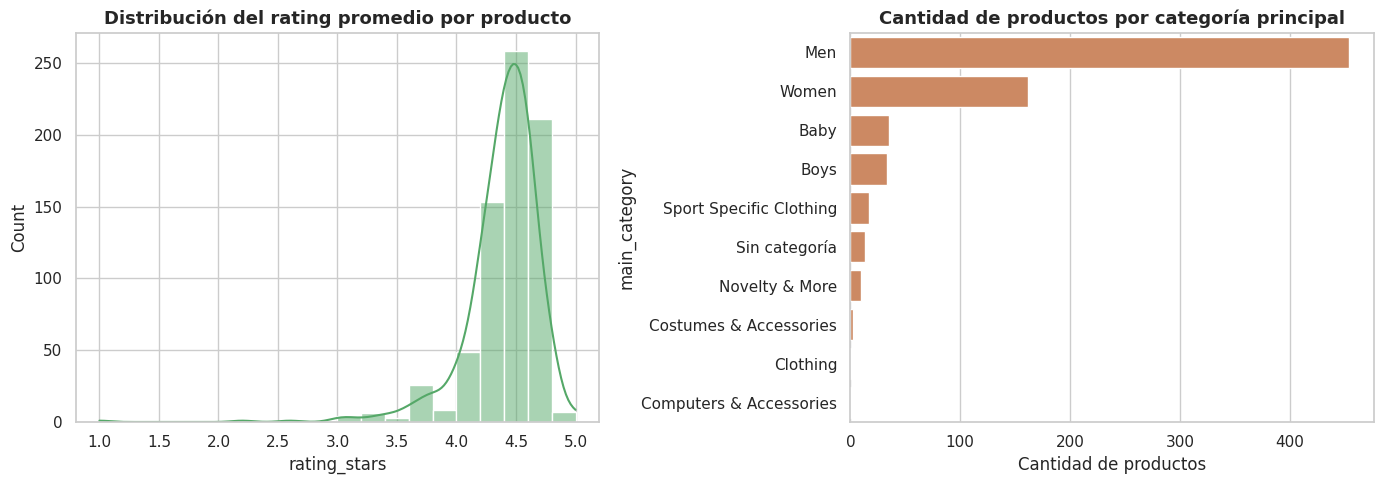

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_products["rating_stars_num"], bins=20, kde=True, ax=axes[0], color="#55A868")
axes[0].set_title("Distribución del rating promedio por producto")
axes[0].set_xlabel("rating_stars")

category_counts = df_products["main_category"].value_counts()
sns.barplot(
    x=category_counts.values,
    y=category_counts.index,
    ax=axes[1],
    color="#DD8452",
)
axes[1].set_title("Cantidad de productos por categoría principal")
axes[1].set_xlabel("Cantidad de productos")

fig.tight_layout()
save_fig(fig, "08_rating_and_category_distribution")
plt.show()

**Hallazgo:** la categoría **"Men"** concentra cerca del **63% del
catálogo**, muy por encima de "Women" (~23%) y el resto de las
categorías. Existe **desbalance de categorías**, relevante para el
filtrado basado en
contenido: un modelo entrenado sin ajustar por esto tenderá a
recomendar productos de las categorías dominantes.

**Decisión:** no se re-balancea el dataset de productos (sería artificial
eliminar/duplicar productos reales), pero se documenta el desbalance para
tenerlo en cuenta al evaluar el recomendador por categoría en la
siguiente etapa (evitar que las métricas agregadas oculten un mal
desempeño en categorías minoritarias).

### 8.3 Compra verificada (`verifiedPurchase`)

In [24]:
verified_counts = df_reviews["verifiedPurchase"].value_counts()
verified_pct = (verified_counts / verified_counts.sum() * 100).round(1)
print(verified_pct)

verifiedPurchase
True     97.6
False     2.4
Name: count, dtype: float64


**Hallazgo:** cerca del **97.6% de las reseñas** provienen de compras
verificadas. Este fuerte desbalance es en realidad una **buena señal de
calidad del dataset** (baja proporción de reseñas potencialmente no
confiables), por lo que no requiere tratamiento — se mantiene como
variable de contexto (posible filtro de confianza en el sistema de
recomendación final).

## 9. Análisis Exploratorio de Datos (EDA)

Con los datos ya limpios y tipados correctamente, se explora la
distribución de precios, marcas, categorías, ratings, reseñas y
sentimiento — insumos clave para el diseño del sistema de recomendación.

### 9.1 Distribución de precios

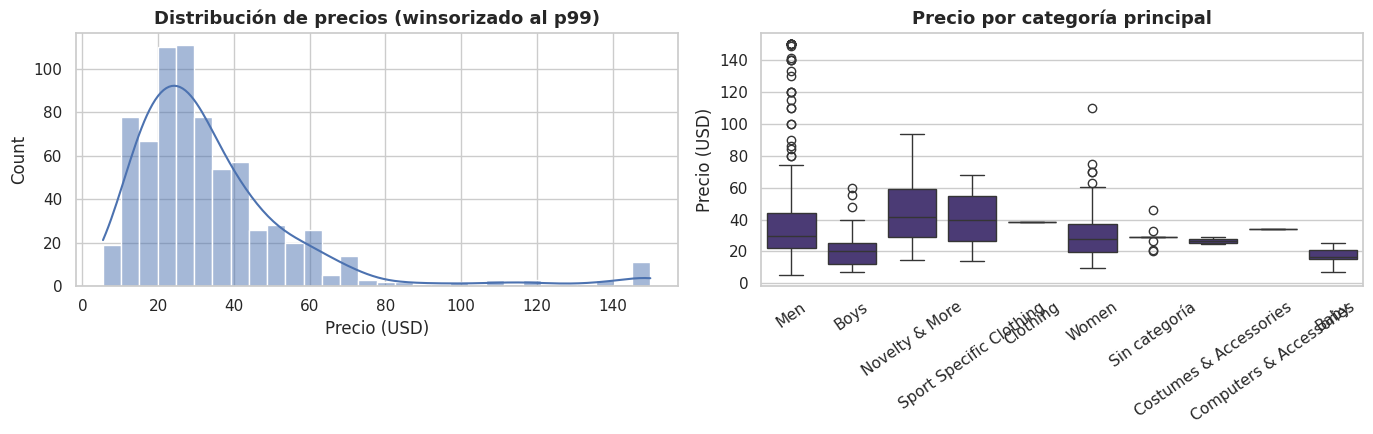

count    728.00
mean      34.89
std       24.54
min        5.46
25%       19.99
50%       28.95
75%       40.01
max      149.99
Name: price_value_winsorized, dtype: float64


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(df_products["price_value_winsorized"], bins=30, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribución de precios (winsorizado al p99)")
axes[0].set_xlabel("Precio (USD)")

sns.boxplot(x=df_products["main_category"], y=df_products["price_value_winsorized"], ax=axes[1])
axes[1].set_title("Precio por categoría principal")
axes[1].tick_params(axis="x", rotation=35)
axes[1].set_xlabel("")
axes[1].set_ylabel("Precio (USD)")

fig.tight_layout()
save_fig(fig, "09_price_distribution")
plt.show()

print(df_products["price_value_winsorized"].describe().round(2))

**Hallazgo:** la mayoría de los productos se ubican entre **USD 15 y
USD 42** (percentiles 25-75), con una cola derecha de prendas premium.
La categoría "Baby" tiende a precios más bajos, mientras que algunas
categorías deportivas muestran mayor dispersión.

### 9.2 Marcas y vendedores más frecuentes

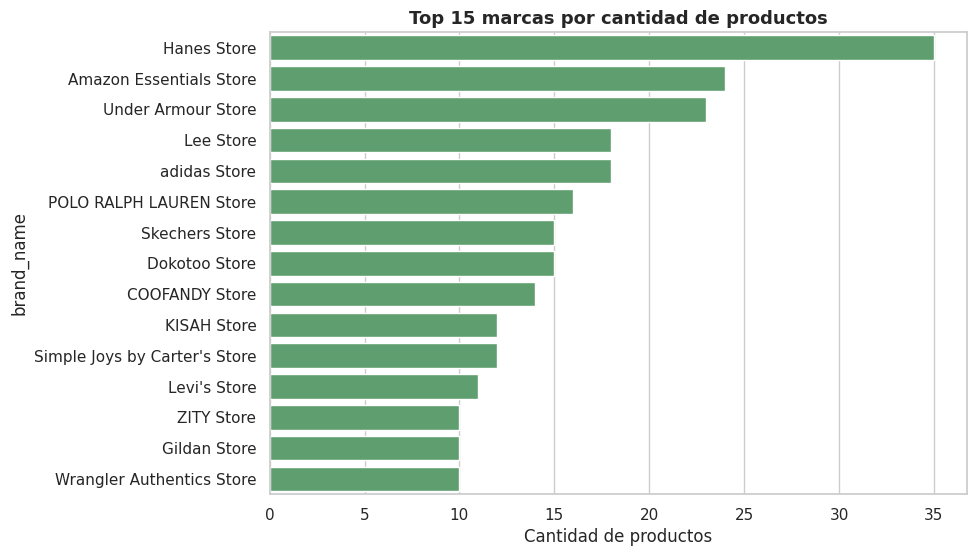

Marcas únicas: 285 sobre 728 productos


In [26]:
top_brands = df_products["brand_name"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=top_brands.values, y=top_brands.index, ax=ax, color="#55A868")
ax.set_title("Top 15 marcas por cantidad de productos")
ax.set_xlabel("Cantidad de productos")
save_fig(fig, "10_top_brands")
plt.show()

print(f"Marcas únicas: {df_products['brand_name'].nunique()} sobre {len(df_products)} productos")

**Hallazgo:** el catálogo es muy fragmentado —**285 marcas distintas**
para 728 productos—, con una larga cola de marcas con muy pocos
productos. Esto refuerza la necesidad de un **filtrado basado en
contenido** (marca, categoría, descripción) para poder recomendar dentro
de nichos de marcas con poco historial de interacciones, mitigando el
problema de *cold start* típico del filtrado puramente colaborativo.

### 9.3 Relación precio vs. rating

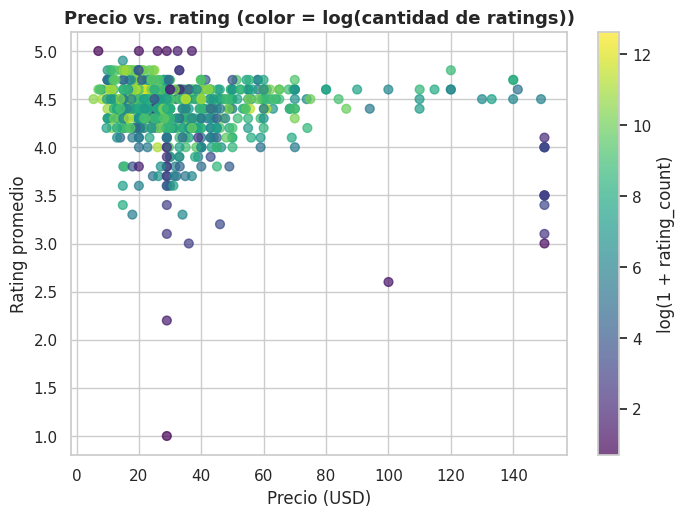

Correlación precio-rating: -0.151


In [27]:
fig, ax = plt.subplots(figsize=(8, 5.5))
scatter = ax.scatter(
    df_products["price_value_winsorized"],
    df_products["rating_stars_num"],
    c=df_products["rating_count_log"],
    cmap="viridis",
    alpha=0.7,
    s=40,
)
ax.set_xlabel("Precio (USD)")
ax.set_ylabel("Rating promedio")
ax.set_title("Precio vs. rating (color = log(cantidad de ratings))")
plt.colorbar(scatter, ax=ax, label="log(1 + rating_count)")
save_fig(fig, "11_price_vs_rating")
plt.show()

corr_price_rating = df_products[["price_value_winsorized", "rating_stars_num"]].corr().iloc[0, 1]
print(f"Correlación precio-rating: {corr_price_rating:.3f}")

**Hallazgo:** la correlación entre precio y rating es débil (~-0.15),
es decir, **el precio prácticamente no predice la satisfacción del
cliente**. Los productos con más ratings (tono más claro) tienden a
concentrarse en rangos de rating altos (4-5), reforzando que el volumen
de reseñas es un buen proxy de popularidad/calidad percibida.

### 9.4 Sentimiento de las reseñas

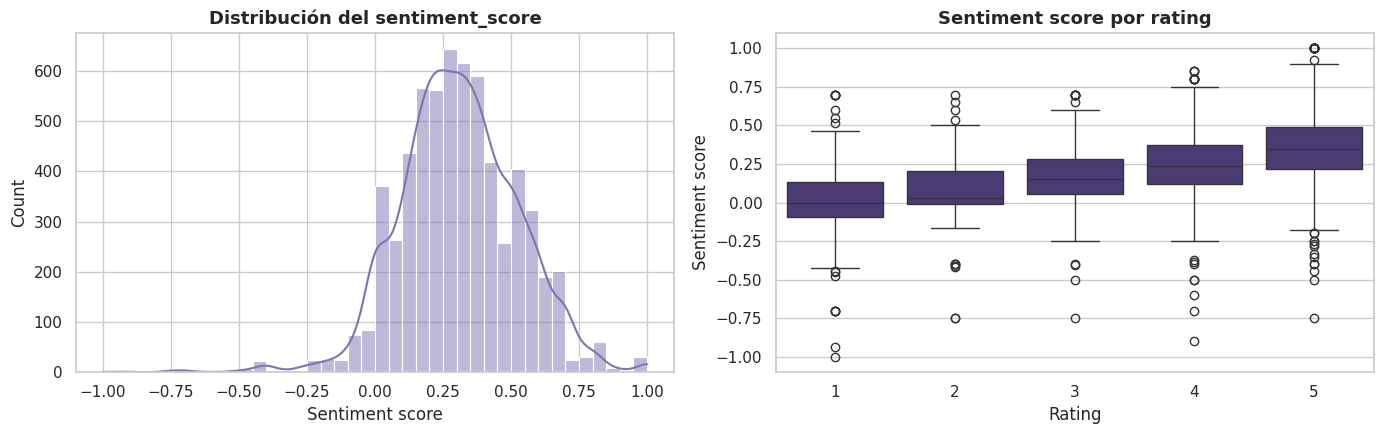

Correlación rating-sentiment_score: 0.365


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(df_reviews["sentiment_score"], bins=40, kde=True, ax=axes[0], color="#8172B2")
axes[0].set_title("Distribución del sentiment_score")
axes[0].set_xlabel("Sentiment score")

sns.boxplot(x=df_reviews["rating"].astype(int), y=df_reviews["sentiment_score"], ax=axes[1])
axes[1].set_title("Sentiment score por rating")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Sentiment score")

fig.tight_layout()
save_fig(fig, "12_sentiment_distribution")
plt.show()

corr_rating_sentiment = df_reviews[["rating", "sentiment_score"]].corr().iloc[0, 1]
print(f"Correlación rating-sentiment_score: {corr_rating_sentiment:.3f}")

**Hallazgo:** existe una correlación positiva moderada entre `rating` y
`sentiment_score`, lo cual **valida la coherencia del dataset**: el
sentimiento del texto tiende a estar alineado con la calificación
numérica. Sin embargo, la correlación no es perfecta, lo que indica que
el texto aporta información adicional a la que solo el rating no
captura (por ejemplo, reseñas de 5 estrellas con comentarios mixtos).

### 9.5 Longitud de reseña, votos útiles y compra verificada

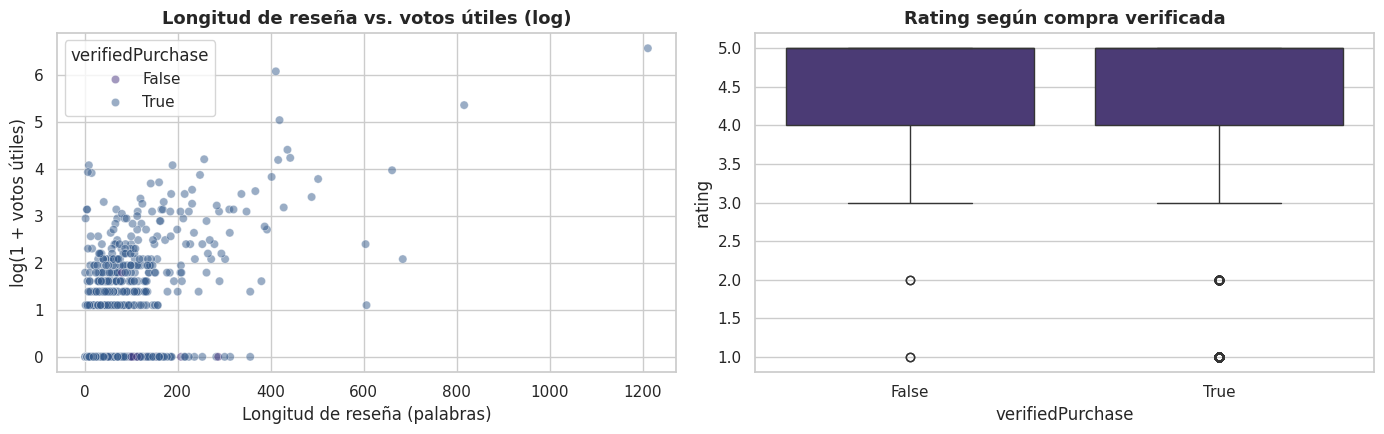

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.scatterplot(
    data=df_reviews.sample(min(1500, len(df_reviews)), random_state=RANDOM_SEED),
    x="review_length_words",
    y="helpful_vote_log",
    hue="verifiedPurchase",
    alpha=0.5,
    ax=axes[0],
)
axes[0].set_title("Longitud de reseña vs. votos útiles (log)")
axes[0].set_xlabel("Longitud de reseña (palabras)")
axes[0].set_ylabel("log(1 + votos útiles)")

sns.boxplot(x="verifiedPurchase", y="rating", data=df_reviews, ax=axes[1])
axes[1].set_title("Rating según compra verificada")

fig.tight_layout()
save_fig(fig, "13_review_length_and_verified")
plt.show()

**Hallazgo:** las reseñas más largas tienden a recibir más votos útiles,
aunque con alta dispersión. No se observan diferencias sustanciales en
el rating entre compras verificadas y no verificadas, lo que sugiere que
`verifiedPurchase` no introduce un sesgo sistemático relevante sobre la
calificación otorgada.

### 9.6 Tendencia temporal de las reseñas

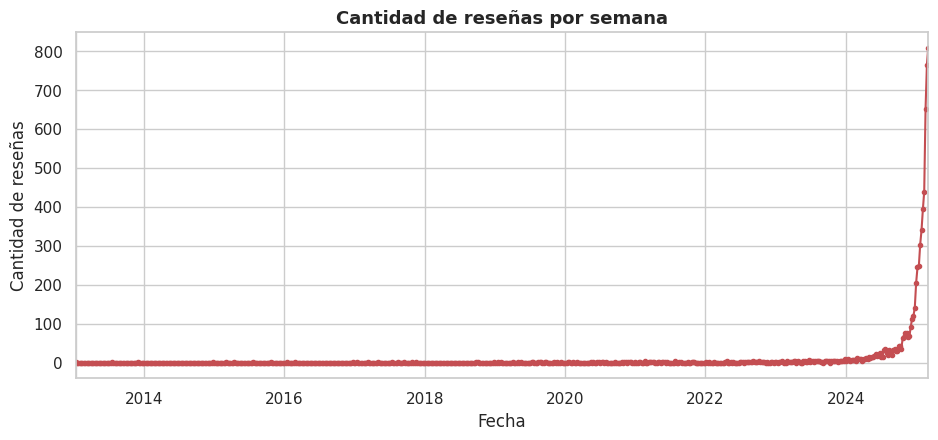

In [30]:
reviews_by_month = (
    df_reviews.dropna(subset=["review_date"])
    .set_index("review_date")
    .resample("W")
    .size()
)

fig, ax = plt.subplots(figsize=(11, 4.5))
reviews_by_month.plot(ax=ax, color="#C44E52", marker="o", markersize=3)
ax.set_title("Cantidad de reseñas por semana")
ax.set_xlabel("Fecha")
ax.set_ylabel("Cantidad de reseñas")
save_fig(fig, "14_reviews_over_time")
plt.show()

**Hallazgo:** el dataset cubre una ventana temporal acotada (scraping
puntual), por lo que la tendencia observada refleja principalmente el
**momento de extracción de los datos** más que estacionalidad real del
negocio. Para un análisis de tendencias de largo plazo se recomendaría
ampliar la ventana de recolección en futuras versiones del dataset.

### 9.7 Dispersión de reseñas por producto (relevante para *cold start*)

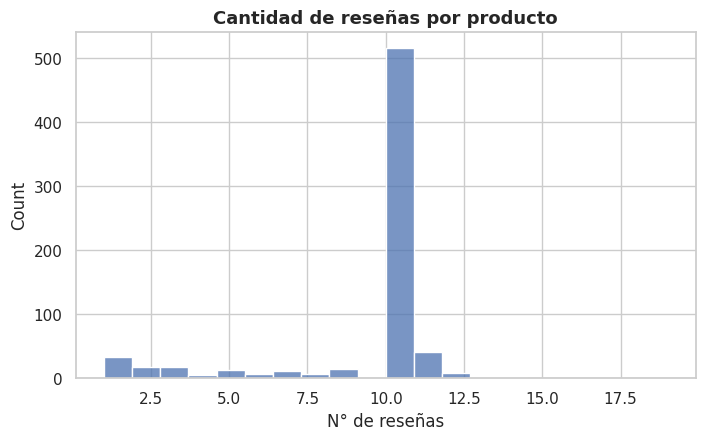

Productos con menos de 5 reseñas: 74 (10.6% del catálogo con reseñas)


In [31]:
reviews_per_product = df_reviews.groupby("productASIN").size()

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(reviews_per_product, bins=20, color="#4C72B0", ax=ax)
ax.set_title("Cantidad de reseñas por producto")
ax.set_xlabel("N° de reseñas")
save_fig(fig, "15_reviews_per_product")
plt.show()

low_review_products = (reviews_per_product < 5).sum()
print(
    f"Productos con menos de 5 reseñas: {low_review_products} "
    f"({low_review_products / len(reviews_per_product):.1%} del catálogo con reseñas)"
)

**Hallazgo:** cada producto tiene entre 1 y 19 reseñas (mediana = 10),
una densidad relativamente uniforme gracias al diseño del scraping. Aun
así, un subconjunto de productos con pocas reseñas representa el
escenario de **cold start de producto**, donde el filtrado colaborativo
puro tendrá baja confiabilidad y el sistema deberá apoyarse más en el
filtrado basado en contenido.

### 9.8 Nubes de palabras: reseñas positivas vs. negativas

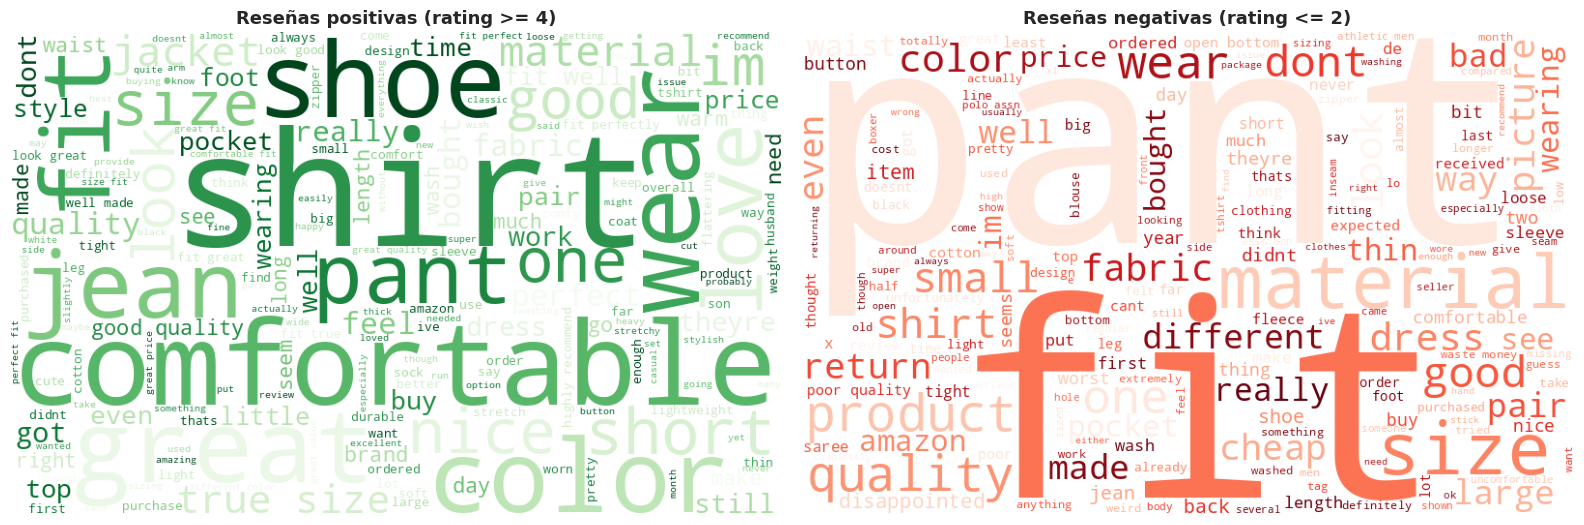

In [32]:
positive_text = " ".join(
    df_reviews.loc[df_reviews["rating"] >= 4, "cleaned_review_text"].dropna()
)
negative_text = " ".join(
    df_reviews.loc[df_reviews["rating"] <= 2, "cleaned_review_text"].dropna()
)

wc_kwargs = dict(width=800, height=500, background_color="white", stopwords=STOPWORDS)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
WordCloud(colormap="Greens", **wc_kwargs).generate(positive_text).to_image()
axes[0].imshow(WordCloud(colormap="Greens", **wc_kwargs).generate(positive_text))
axes[0].axis("off")
axes[0].set_title("Reseñas positivas (rating >= 4)")

axes[1].imshow(WordCloud(colormap="Reds", **wc_kwargs).generate(negative_text))
axes[1].axis("off")
axes[1].set_title("Reseñas negativas (rating <= 2)")

fig.tight_layout()
save_fig(fig, "16_wordclouds_sentiment")
plt.show()

**Hallazgo:** las reseñas positivas destacan atributos de **ajuste,
comodidad y calidad de material**, mientras que las negativas
frecuentemente mencionan **talla, tamaño y calidad percibida**. Esta
información es valiosa como *feature* textual adicional para el sistema
de recomendación basado en contenido (embeddings de texto sobre
`cleaned_review_text`).

### 9.9 Matriz de correlación de variables numéricas clave

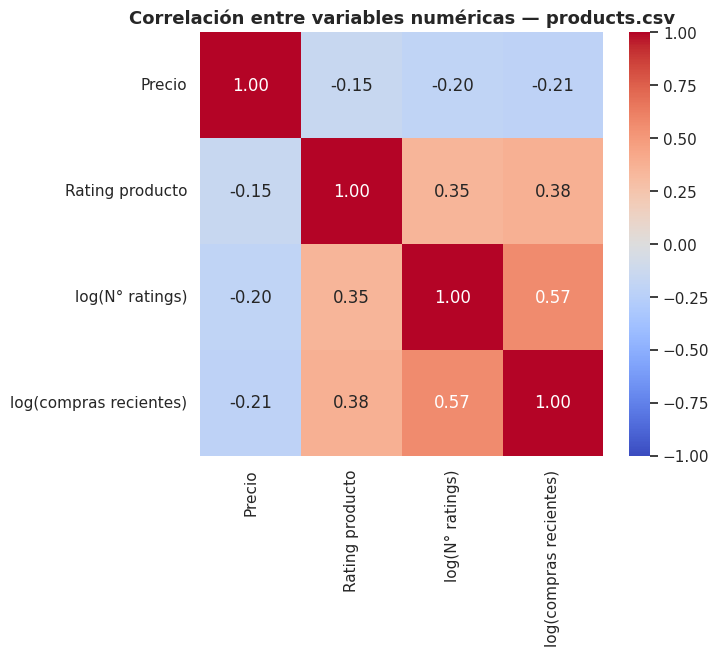

In [33]:
corr_cols = {
    "price_value_winsorized": "Precio",
    "rating_stars_num": "Rating producto",
    "rating_count_log": "log(N° ratings)",
    "recent_purchases_log": "log(compras recientes)",
}
corr_matrix = df_products[list(corr_cols.keys())].rename(columns=corr_cols).corr()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlación entre variables numéricas — products.csv")
save_fig(fig, "17_correlation_heatmap")
plt.show()

**Hallazgo:** `log(N° ratings)` y `log(compras recientes)` muestran una
correlación positiva fuerte (esperable: más compras generan más
reseñas), mientras que `Precio` no está correlacionado de forma
relevante con ninguna otra variable — confirma que el precio debe
tratarse como una **señal independiente** en el modelo de contenido.

## 10. Resumen de calidad de datos (antes vs. después)

In [34]:
quality_summary = pd.DataFrame(
    {
        "métrica": [
            "Filas — products",
            "Filas — reviews",
            "% valores faltantes — products",
            "% valores faltantes — reviews",
            "Columnas numéricas mal tipadas (texto libre)",
            "Outliers de precio tratados (winsorización p99)",
        ],
        "antes": [
            len(df_products_raw),
            len(df_reviews_raw),
            f"{df_products_raw.isna().mean().mean():.1%}",
            f"{df_reviews_raw.isna().mean().mean():.1%}",
            5,
            "No",
        ],
        "después": [
            len(df_products),
            len(df_reviews),
            f"{df_products.isna().mean().mean():.1%}",
            f"{df_reviews.isna().mean().mean():.1%}",
            0,
            "Sí",
        ],
    }
)
quality_summary

,métrica,antes,después
0,Filas — products,728,728
1,Filas — reviews,6327,6288
2,% valores faltantes — products,15.2%,1.1%
3,% valores faltantes — reviews,38.9%,0.0%
4,Columnas numéricas mal tipadas (texto libre),5,0
5,Outliers de precio tratados (winsorización p99),No,Sí


## 11. Principales hallazgos y su impacto en el diseño del recomendador

1. **Integridad estructural sólida**: sin duplicados ni reseñas
   huérfanas — el dataset es confiable como base de un pipeline de
   producción.
2. **Valores faltantes mayormente informativos** (MAR/MNAR): la ausencia
   de `recent_purchases`, `rank_1` o `customer_review_summary` refleja
   bajo volumen de ventas, no errores; se trataron con imputaciones
   justificadas y *flags* booleanos en lugar de imputación ciega.
3. **Outliers legítimos, no ruido**: los precios y conteos extremos
   corresponden a productos reales (premium o *best sellers*); se
   optó por winsorización y transformación logarítmica en vez de
   eliminación, preservando información valiosa para el recomendador.
4. **Fuerte desbalance hacia reseñas positivas (~90% con 4-5 estrellas)**
   y hacia la categoría "Men" (~63% del catálogo): debe considerarse al
   diseñar el split de entrenamiento/validación y al interpretar
   métricas agregadas del modelo.
5. **Catálogo fragmentado en 285 marcas**: refuerza la necesidad de un
   enfoque **híbrido** (contenido + colaborativo) para mitigar el
   problema de *cold start* de productos y marcas con pocas
   interacciones.
6. **Sentimiento textual coherente con el rating**, pero no redundante:
   aporta señal adicional que puede enriquecer el perfil de cada
   producto más allá del rating agregado.
7. **Densidad de reseñas relativamente uniforme por producto** (mediana
   10 reseñas), aunque existe un subconjunto con pocas reseñas que
   representa el escenario de *cold start* a monitorear en la
   evaluación del modelo.

Estos hallazgos sientan las bases para la **Etapa 1**: el próximo
notebook (`02_feature_engineering.ipynb`) construirá el pipeline de
ingeniería de características (encoding de categorías, vectorización de
texto, normalización de variables numéricas) y entrenará los dos
primeros modelos comparativos del MVP del recomendador.

## 12. Exportación de datasets limpios

Se exportan a `data/processed/` para ser consumidos por:
- El informe de **Power BI** del EDA.
- El próximo notebook de **ingeniería de características**.

In [35]:
products_export_cols = [
    "s.no",
    "asin",
    "title",
    "brand_name",
    "manufacturer",
    "model_number",
    "main_category",
    "availability_clean",
    "price_value",
    "price_value_winsorized",
    "list_price_value",
    "rating_stars_num",
    "rating_count_num",
    "rating_count_log",
    "recent_purchases_num",
    "recent_purchases_log",
    "has_recent_purchases",
    "rank_1",
    "has_rank",
    "about_item",
    "product_description",
    "customer_review_summary",
    "product_url",
]
df_products_final = df_products[products_export_cols].rename(columns={"s.no": "s_no"})

reviews_export_cols = [
    "s.no",
    "reviewID",
    "productASIN",
    "productVariant",
    "rating",
    "verifiedPurchase",
    "review_country",
    "review_date",
    "reviewTitle",
    "reviewText",
    "cleaned_review_text",
    "sentiment_score",
    "helpfulVoteCount",
    "helpful_vote_log",
    "review_length_words",
    "has_media",
]
df_reviews_final = df_reviews[reviews_export_cols].rename(columns={"s.no": "s_no"})

df_products_final.to_csv(PROCESSED_DIR / "products_clean.csv", index=False)
df_reviews_final.to_csv(PROCESSED_DIR / "reviews_clean.csv", index=False)

print(f"products_clean.csv -> {df_products_final.shape}")
print(f"reviews_clean.csv  -> {df_reviews_final.shape}")
print(f"Guardado en: {PROCESSED_DIR}")

products_clean.csv -> (728, 23)
reviews_clean.csv  -> (6288, 16)
Guardado en: /home/claude/ShopSmart-Recommender/data/processed


## 13. Próximos pasos

- [ ] Conectar `data/processed/*.csv` a un informe de **Power BI** con
  visualizaciones interactivas (distribución de precios, mapa de
  categorías, evolución de sentimiento).
- [ ] Notebook `02_feature_engineering.ipynb`: pipeline de
  `sklearn.Pipeline`/`ColumnTransformer` para encoding, escalado y
  vectorización de texto (TF-IDF / embeddings).
- [ ] Entrenar y comparar al menos dos modelos base de recomendación
  (ej. similitud de contenido con TF-IDF vs. filtrado colaborativo con
  *matrix factorization*) como MVP de la Etapa 1.